In [ ]:
import numpy as np
import pandas as pd
import re
import html
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('recipe_reviews.csv')
print(f'Dataset Shape: {df.shape}')
df.head(2)

Dataset Shape: (18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...


In [ ]:
df = df.dropna(subset=['text', 'stars']).copy()
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
df = df[(df['stars'] >= 1) & (df['stars'] <= 5)]
print('After cleaning:', df.shape)
print('Star distribution:')
print(df['stars'].value_counts().sort_index())

After cleaning: (16484, 15)
Star distribution:
stars
1      280
2      232
3      490
4     1655
5    13827
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = html.unescape(str(text))
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z!? ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)
print('Text cleaning done.')

Text cleaning done.


In [ ]:
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))
df['exclamation'] = df['text'].str.count('!')
df['questions']   = df['text'].str.count(r'\?')

POS_WORDS = {'great','amazing','delicious','perfect','wonderful','love','excellent',
             'fantastic','awesome','good','nice','tasty','easy','simple'}
NEG_WORDS = {'bad','terrible','awful','worst','disgusting','bland','boring','dry','hard'}

def lex_features(text):
    words = text.split()
    pos = sum(w in POS_WORDS for w in words)
    neg = sum(w in NEG_WORDS for w in words)
    return pd.Series([pos, neg])

df[['lex_pos', 'lex_neg']] = df['text'].apply(lex_features)
df[['text_length','word_count','exclamation','questions','lex_pos','lex_neg']].describe()

,text_length,word_count,exclamation,questions,lex_pos,lex_neg
count,16484.000000,16484.000000,16484.000000,16484.000000,16484.00000,16484.000000
mean,197.244661,38.705533,1.169012,0.062606,0.95711,0.045074
std,165.497251,32.631270,1.699666,0.430401,0.98230,0.233086
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,87.000000,17.000000,0.000000,0.000000,0.00000,0.000000
50%,157.000000,31.000000,1.000000,0.000000,1.00000,0.000000
75%,259.000000,51.000000,2.000000,0.000000,1.00000,0.000000
max,2601.000000,506.000000,43.000000,16.000000,9.00000,6.000000


In [ ]:
META_COLS = [
    'user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down', 'best_score',
    'text_length', 'word_count', 'exclamation', 'questions', 'lex_pos', 'lex_neg'
]

META_COLS = [c for c in META_COLS if c in df.columns]
df[META_COLS] = df[META_COLS].fillna(0)
print('Meta cols used:', META_COLS)

Meta cols used: ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down', 'best_score', 'text_length', 'word_count', 'exclamation', 'questions', 'lex_pos', 'lex_neg']


In [ ]:
MINORITY_CLASSES = [1, 2, 3]
WINDOW_WORDS     = 15
STEP_WORDS       = 7

def sliding_window_augment(df_in, minority_classes, win, step):
    aug_rows = []
    for _, row in df_in[df_in['stars'].isin(minority_classes)].iterrows():
        words = row['text'].split()
        if len(words) <= win:
            aug_rows.append(row.to_dict())
            continue
        for start in range(0, len(words) - win + 1, step):
            nr = row.to_dict()
            chunk = ' '.join(words[start:start + win])
            nr['text']         = chunk
            nr['text_length']  = len(chunk)
            nr['word_count']   = win
            lex = lex_features(chunk)
            nr['lex_pos']      = lex.iloc[0]
            nr['lex_neg']      = lex.iloc[1]
            nr['exclamation']  = chunk.count('!')
            nr['questions']    = chunk.count('?')
            aug_rows.append(nr)
    return pd.DataFrame(aug_rows)

aug_minority = sliding_window_augment(df, MINORITY_CLASSES, WINDOW_WORDS, STEP_WORDS)
df_majority  = df[~df['stars'].isin(MINORITY_CLASSES)].copy()
df_augmented = pd.concat([df_majority, aug_minority], ignore_index=True)

print('Class distribution after augmentation:')
orig_dist = df['stars'].value_counts().sort_index()
new_dist  = df_augmented['stars'].value_counts().sort_index()
comparison = pd.DataFrame({
    'Original': orig_dist,
    'After Augmentation': new_dist,
    'Increase Factor': (new_dist / orig_dist).round(1)
})
print(comparison.to_string())
print(f'\nTotal rows: {len(df)} -> {len(df_augmented)} (+{len(df_augmented)-len(df):,})')

Class distribution after augmentation:
       Original  After Augmentation  Increase Factor
stars                                               
1           280                1202              4.3
2           232                1152              5.0
3           490                2372              4.8
4          1655                1655              1.0
5         13827               13827              1.0

Total rows: 16484 -> 20208 (+3,724)


In [ ]:
X_text = df_augmented['text']
X_meta = df_augmented[META_COLS]
y      = df_augmented['stars']

X_tr_text, X_te_text, X_tr_meta, X_te_meta, y_tr, y_te = train_test_split(
    X_text, X_meta, y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {len(X_tr_text):,}  |  Test: {len(X_te_text):,}')

Train: 16,166  |  Test: 4,042


In [ ]:
word_tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=40000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=20000
)

X_tr_word = word_tfidf.fit_transform(X_tr_text)
X_te_word = word_tfidf.transform(X_te_text)

X_tr_char = char_tfidf.fit_transform(X_tr_text)
X_te_char = char_tfidf.transform(X_te_text)

print(f'Word TF-IDF: {X_tr_word.shape}')
print(f'Char TF-IDF: {X_tr_char.shape}')

Word TF-IDF: (16166, 17542)
Char TF-IDF: (16166, 20000)


In [ ]:
scaler = StandardScaler()
X_tr_meta_scaled = scaler.fit_transform(X_tr_meta)
X_te_meta_scaled = scaler.transform(X_te_meta)
print('Scaling done.')

Scaling done.


In [ ]:
X_tr = hstack([X_tr_word, X_tr_char, X_tr_meta_scaled])
X_te = hstack([X_te_word, X_te_char, X_te_meta_scaled])

print(f'Final feature space — Train: {X_tr.shape}  |  Test: {X_te.shape}')

Final feature space — Train: (16166, 37553)  |  Test: (4042, 37553)


In [ ]:
freq    = y_tr.value_counts().to_dict()
weights = y_tr.map(lambda x: 1 / freq[x])
print('Sample weight summary:')
print(weights.describe())

Sample weight summary:
count    16166.000000
mean         0.000309
std          0.000346
min          0.000091
25%          0.000091
50%          0.000091
75%          0.000523
max          0.001082
Name: stars, dtype: float64


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_grid = {'alpha': [0.01, 0.1, 1, 5, 10, 20]}
# lasso_grid = {'alpha': [0.0005, 0.001, 0.005, 0.01, 0.05]}

ridge_search = GridSearchCV(
    Ridge(), ridge_grid, cv=cv,
    scoring='neg_mean_absolute_error', n_jobs=-1
)

print('Fitting Ridge...')
ridge_search.fit(X_tr, y_tr, sample_weight=weights)
print(f'  Best alpha: {ridge_search.best_params_}')

Fitting Ridge...
  Best alpha: {'alpha': 0.01}


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_tr, y_tr, sample_weight=weights)

models = {
    'Linear': linear_model,
    'Ridge':  ridge_search.best_estimator_,
    #'Lasso':  lasso_search.best_estimator_,
}

print('Best Ridge alpha :', ridge_search.best_params_)
#print('Best Lasso alpha :', lasso_search.best_params_)

Best Ridge alpha : {'alpha': 0.01}


In [ ]:
results    = []
all_preds  = {}

for name, model in models.items():
    preds = model.predict(X_te).clip(1, 5)
    all_preds[name] = preds

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    tol1 = np.mean(np.abs(y_te - preds) <= 1.0)
    tol05= np.mean(np.abs(y_te - preds) <= 0.5)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse,
                    'R2': r2, '+-0.5': tol05, '+-1.0': tol1})

results_df = pd.DataFrame(results).round(4).sort_values('MAE')
display(results_df)

,Model,MAE,RMSE,R2,+-0.5,+-1.0
0,Linear,0.8010,1.2451,-0.0547,0.5114,0.6900
1,Ridge,0.8399,1.0281,0.2809,0.3308,0.6252


In [ ]:
print('=== Model Comparison Summary ===')
display(results_df.set_index('Model'))

best = results_df.iloc[0]
print(f"\nBest model by MAE : {best['Model']}  (MAE={best['MAE']:.4f}, RMSE={best['RMSE']:.4f})")

=== Model Comparison Summary ===


,MAE,RMSE,R2,+-0.5,+-1.0
Model,,,,,
Linear,0.8010,1.2451,-0.0547,0.5114,0.6900
Ridge,0.8399,1.0281,0.2809,0.3308,0.6252



Best model by MAE : Linear  (MAE=0.8010, RMSE=1.2451)


In [ ]:
# 5-class thresholds (midpoints between integer star values)
# Class 1: pred < 1.5
# Class 2: 1.5 <= pred < 2.5
# Class 3: 2.5 <= pred < 3.5
# Class 4: 3.5 <= pred < 4.5
# Class 5: pred >= 4.5

def bucket(pred):
    """Map continuous regression output to a 1-5 star class."""
    if pred < 1.5:   return 1
    elif pred < 2.5: return 2
    elif pred < 3.5: return 3
    elif pred < 4.5: return 4
    else:            return 5

def bucket_true(stars):
    """Round true star rating to nearest integer class (1-5)."""
    return int(round(float(stars)))

star_order = [1, 2, 3, 4, 5]

print('5-class thresholds:')
print('  Class 1 : pred < 1.5')
print('  Class 2 : 1.5 <= pred < 2.5')
print('  Class 3 : 2.5 <= pred < 3.5')
print('  Class 4 : 3.5 <= pred < 4.5')
print('  Class 5 : pred >= 4.5')


5-class thresholds:
  Class 1 : pred < 1.5
  Class 2 : 1.5 <= pred < 2.5
  Class 3 : 2.5 <= pred < 3.5
  Class 4 : 3.5 <= pred < 4.5
  Class 5 : pred >= 4.5


In [ ]:
best_preds  = all_preds[best_model_name]
y_te_reset  = y_te.reset_index(drop=True)

X_te_text_reset = X_te_text.reset_index(drop=True)

error_df = pd.DataFrame({
    'text':          X_te_text_reset.values,
    'true_stars':    y_te_reset.values,
    'pred_stars':    best_preds,
    'abs_error':     np.abs(y_te_reset.values - best_preds),
    'error':         y_te_reset.values - best_preds,
    'true_class':    [bucket_true(s) for s in y_te_reset.values],
    'pred_class':    [bucket(p) for p in best_preds],
})

error_df['true_bucket']  = error_df['true_class']
error_df['pred_bucket']  = error_df['pred_class']
error_df['bucket_match'] = error_df['true_class'] == error_df['pred_class']
error_df['within_1star'] = error_df['abs_error'] <= 1.0

print(f'Test samples          : {len(error_df):,}')
print(f'Exact class match     : {error_df["bucket_match"].mean():.1%}')
print(f'Within ±1 star        : {error_df["within_1star"].mean():.1%}')
print(f'Mean absolute error   : {error_df["abs_error"].mean():.4f}')
error_df.head(5)


Test samples          : 4,042
Exact class match     : 51.1%
Within ±1 star        : 69.0%
Mean absolute error   : 0.8010


,text,true_stars,pred_stars,abs_error,error,true_class,pred_class,true_bucket,pred_bucket,bucket_match,within_1star
0,this is such a versatile and great recipe i do...,5,4.538838,0.461162,0.461162,5,5,5,5,True,True
1,omg!! what a delicious soup! only made adjustm...,5,2.235398,2.764602,2.764602,5,2,5,2,False,False
2,was due to the potatoes which really need to b...,2,2.169981,0.169981,-0.169981,2,2,2,2,True,True
3,hi! i love making bread i used to make it the ...,5,3.036437,1.963563,1.963563,5,3,5,3,False,False
4,entered this chili in a chili cook off contest...,5,5.000000,0.000000,0.000000,5,5,5,5,True,True


In [ ]:
print(f'=== Top 10 Worst Predictions ({best_model_name}) ===')
worst = error_df.sort_values('abs_error', ascending=False).head(10)
display(worst[['text','true_stars','pred_stars','abs_error','true_bucket','pred_bucket']]
        .assign(text=lambda df: df['text'].str[:200])
        .reset_index(drop=True))

=== Top 10 Worst Predictions (Linear) ===


,text,true_stars,pred_stars,abs_error,true_bucket,pred_bucket
0,for it at all he loves everything i make for h...,1,5.0,4.0,1,5
1,i am a vegan so don t use eggs butter or dairy...,5,1.0,4.0,5,1
2,good go to recipe i sometimes use cubes of sal...,5,1.0,4.0,5,1
3,at a loss how this recipe became a contest win...,1,5.0,4.0,1,5
4,this recipe was given to me by my neighbor i t...,1,5.0,4.0,1,5
5,i will definitely make this i like every singl...,5,1.0,4.0,5,1
6,absolutely outstanding! these fajitas are bett...,5,1.0,4.0,5,1
7,this is a delicious casserole! it does take so...,5,1.0,4.0,5,1
8,very good made for faimly,5,1.0,4.0,5,1
9,can these rhubarb bars be frozen after baking?,5,1.0,4.0,5,1


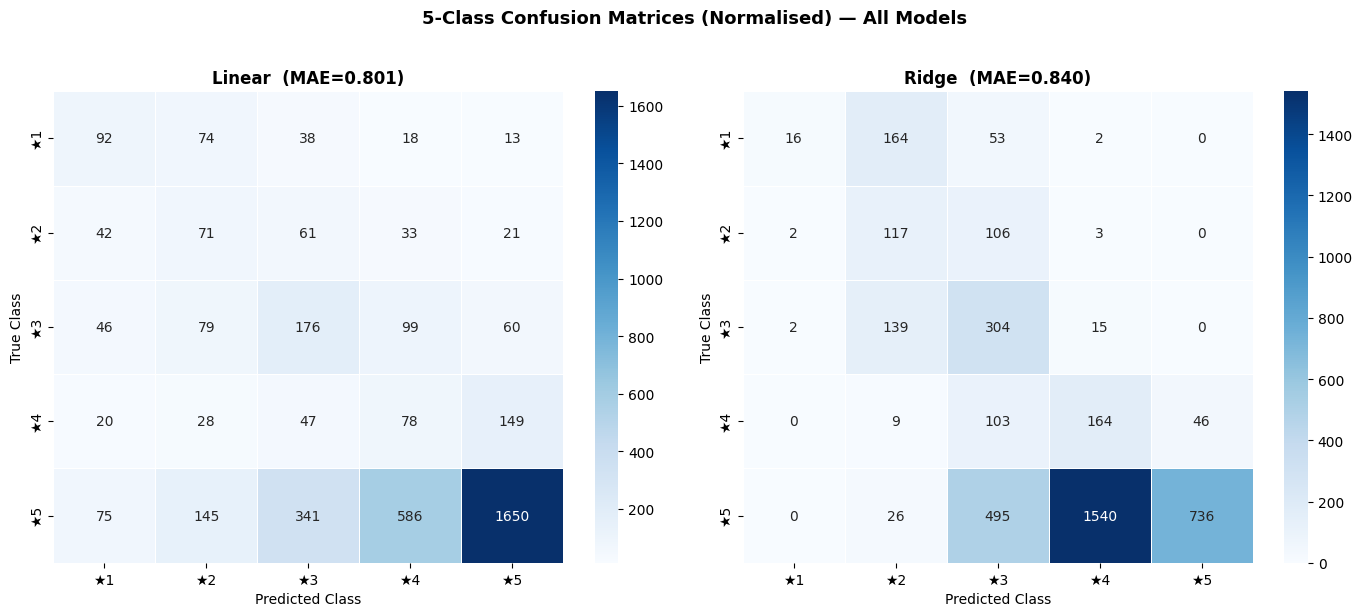

In [ ]:
star_order = [1, 2, 3, 4, 5]
n_models = len(all_preds)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, all_preds.items()):
    pred_classes = [bucket(p) for p in preds]
    true_classes = [bucket_true(s) for s in y_te_reset.values]
    cm = confusion_matrix(true_classes, pred_classes, labels=star_order)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'{s}' for s in star_order],
                yticklabels=[f'{s}' for s in star_order],
                linewidths=0.5, ax=ax)
    mae_val = results_df[results_df['Model']==name]['MAE'].values[0]
    ax.set_title(f'{name}  (MAE={mae_val:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')

plt.suptitle('5-Class Confusion Matrices — Linear/Ridge',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
true_buckets = [bucket_true(s) for s in y_te_reset.values]

summary_rows = []
for name, preds in all_preds.items():
    pred_buckets  = [bucket(p) for p in preds]
    bucket_acc    = np.mean([t==p for t,p in zip(true_buckets, pred_buckets)])
    mae_val       = results_df[results_df['Model']==name]['MAE'].values[0]
    rmse_val      = results_df[results_df['Model']==name]['RMSE'].values[0]
    r2_val        = results_df[results_df['Model']==name]['R2'].values[0]
    tol05_val     = results_df[results_df['Model']==name]['+-0.5'].values[0]
    tol1_val      = results_df[results_df['Model']==name]['+-1.0'].values[0]

    summary_rows.append({
        'Model':           name,
        'MAE':             mae_val,
        'RMSE':            rmse_val,
        'R²':              r2_val,
        'Within +-0.5 star':    tol05_val,
        'Within +-1.0 star':    tol1_val,
        'Class Accuracy (exact)': round(bucket_acc, 4),
    })

final_summary = pd.DataFrame(summary_rows).sort_values('MAE').set_index('Model')
print('=== Final Model Summary ===')
display(final_summary)

=== Final Model Summary ===


,MAE,RMSE,R²,Within ±0.5★,Within ±1.0★,Class Accuracy (exact)
Model,,,,,,
Linear,0.8010,1.2451,-0.0547,0.5114,0.6900,0.5114
Ridge,0.8399,1.0281,0.2809,0.3308,0.6252,0.3308
